# Heart Disease Prediction Workflow
This notebook covers a full data science pipeline for disease prediction, including:
- Data Preprocessing and Wrangling
- Descriptive Statistics and Data Analytics
- Data Visualization
- Handling of Outliers (Detection & Removal)
- Data Normalization (Standardization)
- Model Training (3 Algorithms)
- Hyperparameter Tuning
- Comparison of Models


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


## 1. Data Preprocessing & Data Wrangling
Looking at the dataset structure, handling null values if any.


In [2]:
# Load dataset
df = pd.read_csv("HeartDisease.csv")
display(df.head())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Checking for null values
print("Missing values in each column:\n", df.isnull().sum())

# Dropping null values (if any)
df.dropna(inplace=True)
print("\nShape of dataset after removing nulls:", df.shape)


Missing values in each column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Shape of dataset after removing nulls: (303, 14)


## 2. Descriptive Statistics & Data Analytics
Understanding the basic statistical measures of our continuous features and checking our target distribution.


In [4]:
display(df.describe())
display(df.info())

# Target Distribution
print("\nTarget Value Counts:")
print(df['target'].value_counts())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


None


Target Value Counts:
target
1    165
0    138
Name: count, dtype: int64


## 3. Data Visualization
Plotting a correlation heatmap and histograms.


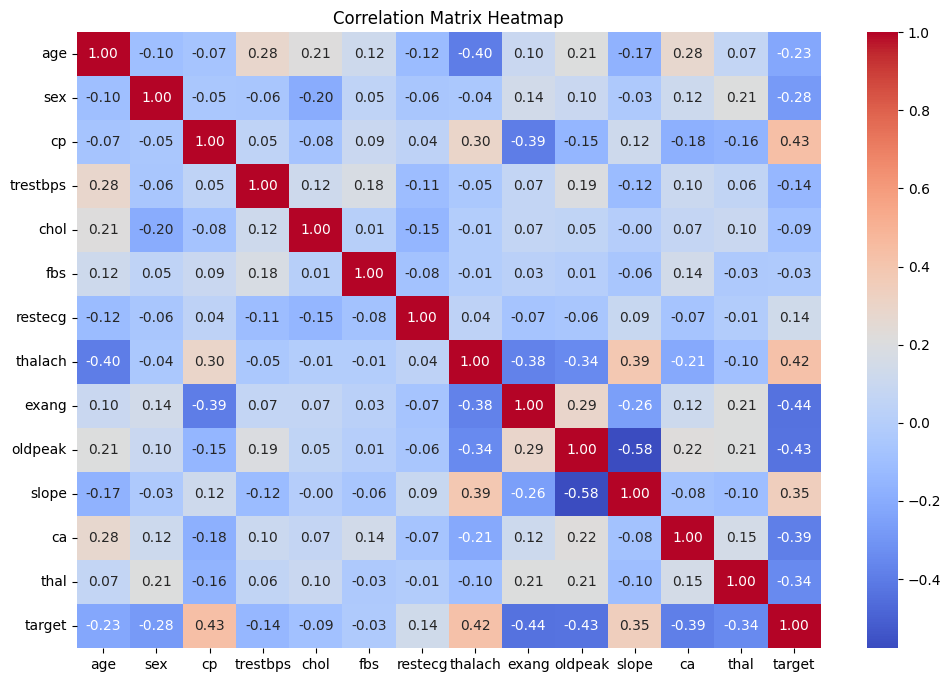

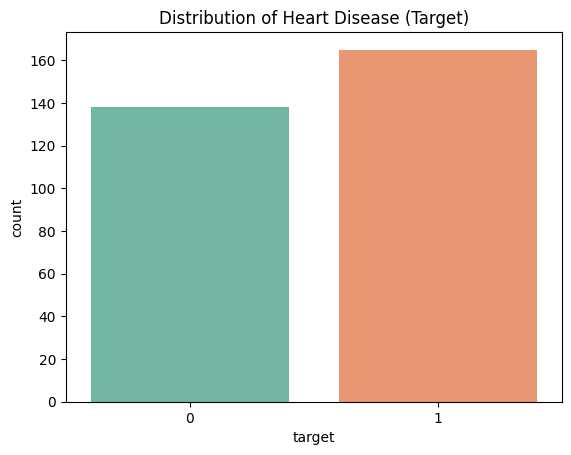

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

# Distribution of Target
sns.countplot(x='target', data=df, palette='Set2')
plt.title("Distribution of Heart Disease (Target)")
plt.show()


## 4. Outliers Detection and Removal
We utilize boxplots to detect outliers in continuous variables visually, then apply the Z-score method to securely remove extreme outliers.


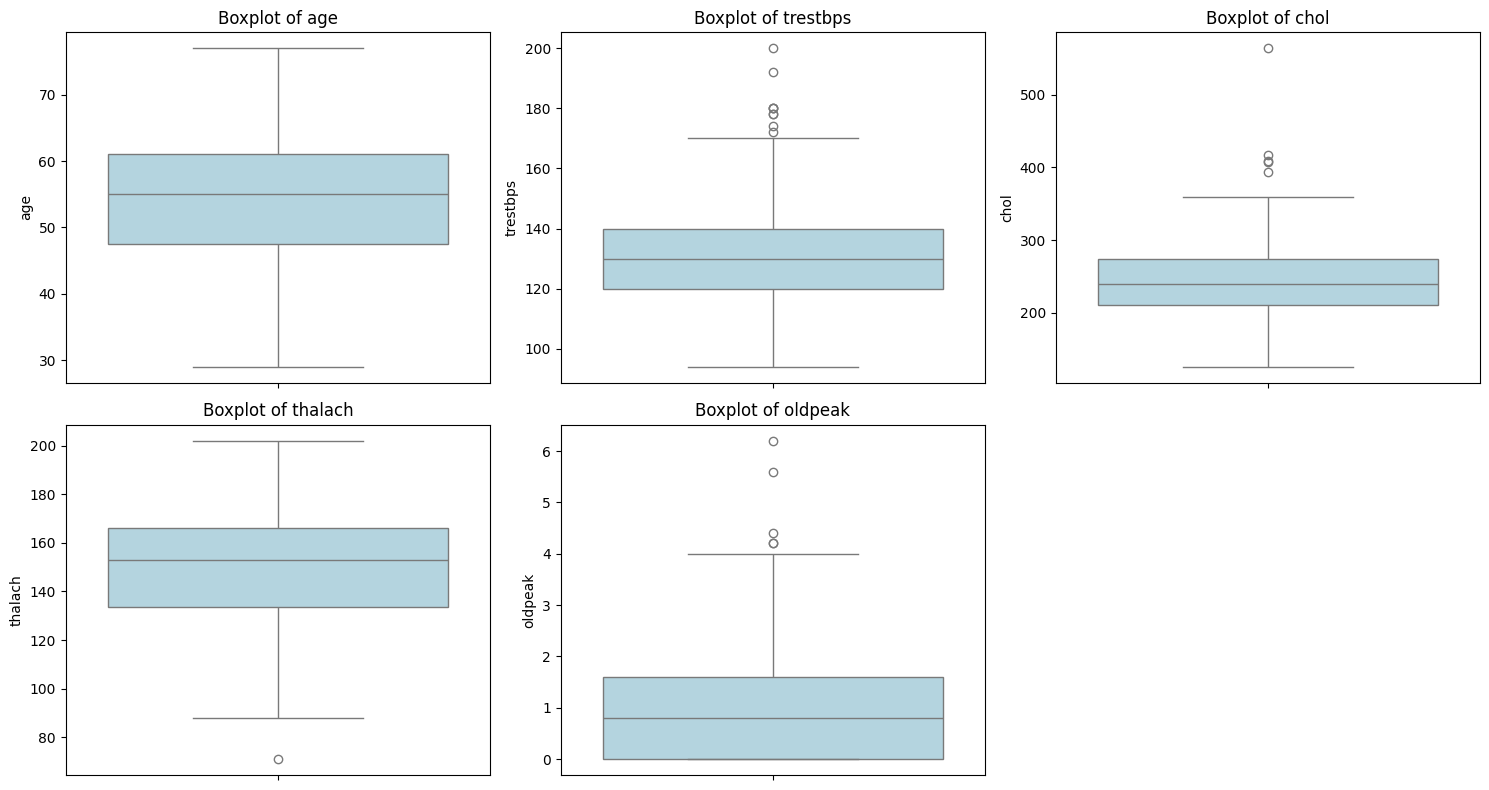

In [6]:
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(15, 8))
for i, col in enumerate(continuous_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [7]:
# Outlier Removal using Z-Score (threshold = 3)
z_scores = np.abs(stats.zscore(df[continuous_features]))
df_clean = df[(z_scores < 3).all(axis=1)]

print(f"Original Dataset Shape: {df.shape}")
print(f"Cleaned Dataset Shape: {df_clean.shape}")
print(f"Removed {len(df) - len(df_clean)} outlier rows.")


Original Dataset Shape: (303, 14)
Cleaned Dataset Shape: (294, 14)
Removed 9 outlier rows.


## 5. Data Normalization and Splitting
Next, we separate target from features, one-hot encode categorical features, and standardize continuous features so distance-based models (like SVC) perform optimally.


In [8]:
# Separating target and features
X = df_clean.drop("target", axis=1)
y = df_clean["target"].values

# One-Hot Encoding for Categorical Features
categorical_features = ["cp", "slope", "ca", "restecg", "thal"]
# Ensuring columns exist in X before get_dummies (in case they differ)
cat_cols = [col for col in categorical_features if col in X.columns]
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Feature Standardization on Continuous Features
scaler = StandardScaler()
# Ensuring continuous columns exist
cont_cols = [col for col in continuous_features if col in X.columns]
X[cont_cols] = scaler.fit_transform(X[cont_cols])

display(X.head())

# Splitting into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_1,cp_2,...,slope_2,ca_1,ca_2,ca_3,ca_4,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,0.969920,1,0.830906,-0.232573,1,0.004999,0,1.223393,False,False,...,False,False,False,False,False,False,False,True,False,False
1,-1.888241,1,-0.063043,0.138801,0,1.652914,0,2.340694,False,True,...,False,False,False,False,False,True,False,False,True,False
2,-1.448524,0,-0.063043,-0.866093,0,0.984840,0,0.385418,True,False,...,True,False,False,False,False,False,False,False,True,False
3,0.200415,1,-0.659009,-0.167037,0,1.252070,0,-0.173232,True,False,...,True,False,False,False,False,True,False,False,True,False
4,0.310345,0,-0.659009,2.410735,0,0.583996,1,-0.359449,False,False,...,True,False,False,False,False,True,False,False,True,False


Training Data Shape: (235, 22)
Test Data Shape: (59, 22)


## 6. Model Training (3 Algorithms) & 7. Hyperparameter Tuning
We will implement Logistic Regression, Random Forest, and Support Vector Classifier (SVC). 
We also apply GridSearchCV for hyperparameter tuning.


In [9]:
# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# 2. Random Forest with Hyperparameter Tuning
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
print("Best Random Forest Parameters:", rf_grid.best_params_)

# 3. SVC with Hyperparameter Tuning
svc_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}
svc_grid = GridSearchCV(SVC(random_state=42), svc_params, cv=5, scoring='accuracy', n_jobs=-1)
svc_grid.fit(X_train, y_train)
svc_best = svc_grid.best_estimator_
svc_pred = svc_best.predict(X_test)
print("Best SVC Parameters:", svc_grid.best_params_)


Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best SVC Parameters: {'C': 1, 'kernel': 'linear'}


## 8. Comparison of Models
We compare the tuned models based on Accuracy, Precision, Recall, and F1-Score.


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.898305,0.911765,0.911765,0.911765
1,Random Forest (Tuned),0.813559,0.848485,0.823529,0.835821
2,SVC (Tuned),0.898305,0.911765,0.911765,0.911765


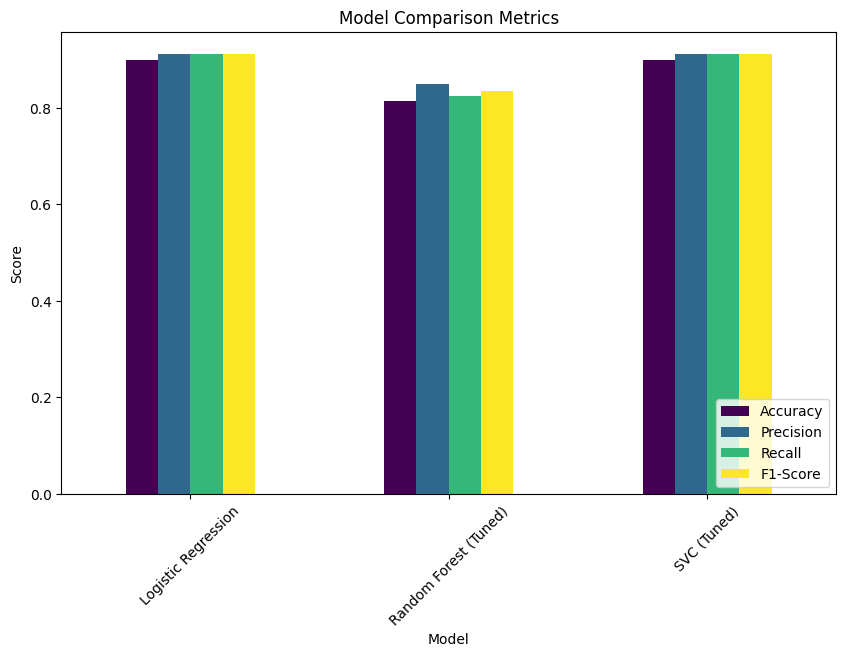

In [10]:
def evaluate_model(name, y_true, y_preds):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_preds),
        "Precision": precision_score(y_true, y_preds),
        "Recall": recall_score(y_true, y_preds),
        "F1-Score": f1_score(y_true, y_preds)
    }

results = []
results.append(evaluate_model("Logistic Regression", y_test, lr_pred))
results.append(evaluate_model("Random Forest (Tuned)", y_test, rf_pred))
results.append(evaluate_model("SVC (Tuned)", y_test, svc_pred))

results_df = pd.DataFrame(results)
display(results_df)

# Plotting Comparison
results_df.set_index("Model").plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Model Comparison Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.show()
